# Plots for Iron
Benjamin Floyd

Small notebook to generate some new plots for Iron presentations/paper

In [1]:
import numpy as np
import yaml
import matplotlib.pyplot as plt
import fitsio
from astropy.table import Table, vstack, hstack
from desiutil.bitmask import BitMask
from pathlib import Path
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
from desitarget.targets import desi_mask, bgs_mask, scnd_mask
import warnings

# Settings for matplotlib plots
settings = {
    'font.size': 14,
    'axes.linewidth': 2.0,
    'xtick.major.size': 6.0,
    'xtick.minor.size': 4.0,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.,
    'xtick.direction': 'in',
    'xtick.minor.visible': True,
    'xtick.top': True,
    'ytick.major.size': 6.0,
    'ytick.minor.size': 4.0,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.,
    'ytick.direction': 'in',
    'ytick.minor.visible': True,
    'ytick.right': True,
    'axes.labelsize': 14,
    'legend.fontsize': 14
}

plt.rcdefaults()  # Makes sure all settings are default then applied.
plt.rcParams.update(**settings)

In [2]:
with open('/global/u2/b/bfloyd/agngal_dr2/AgnCats/py/agnmask.yaml', 'r') as f:
    agn_defs = yaml.safe_load(f)

agn_maskbits = BitMask('AGN_MASKBITS', agn_defs)
opt_uv_type = BitMask('OPT_UV_TYPE', agn_defs)
ir_type = BitMask('IR_TYPE', agn_defs)

In [3]:
# Read in a limited catalog of all survey programs of Loa
iron_dir = Path('/global/cfs/cdirs/desi/users/bfloyd/agngal_vac/iron/v3.0/')
agngal = []
for fname in iron_dir.iterdir():
    subcat_ext1 = Table(fitsio.read(str(fname), ext=1,
                                    columns=['TARGETID', 'Z', 'ZWARN', 'DESI_TARGET', 'SCND_TARGET', 'BGS_TARGET',
                                             'AGN_MASKBITS', 'OPT_UV_TYPE', 'IR_TYPE']))
    subcat_ext2 = Table(fitsio.read(str(fname), ext=2,
                                    columns=['FLUX_W1', 'FLUX_IVAR_W1', 'FLUX_W2', 'FLUX_IVAR_W2', 'FLUX_W3',
                                             'FLUX_IVAR_W3']))

    subcat = hstack([subcat_ext1, subcat_ext2])
    agngal.append(subcat)
agngal = vstack(agngal)

In [4]:
# AB-Vega offsets
w1_ab_vega_offset = 2.699
w2_ab_vega_offset = 3.339
w3_ab_vega_offset = 5.174

w1w2_ab_vega_offset = w1_ab_vega_offset - w2_ab_vega_offset
w2w3_ab_vega_offset = w2_ab_vega_offset - w3_ab_vega_offset

In [5]:
# IR-AGN plots
# Using bitmasks - this is at fixed S/N threshold of >3
has_w1w2 = agngal['IR_TYPE'] & ir_type.WISE_W12 == ir_type.WISE_W12
has_w1w2_only = (agngal['IR_TYPE'] & ir_type.WISE_W12 == ir_type.WISE_W12) & (
            agngal['IR_TYPE'] & ir_type.WISE_W123 == 0)
has_w1w2w3 = agngal['IR_TYPE'] & ir_type.WISE_W123 == ir_type.WISE_W123

## WISE colors and W2 mag in AB magnitudes (W1-W2 and W2-W3)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    mag_w1 = -2.5 * np.log10(agngal['FLUX_W1']) + 22.5  # W2 mag
    mag_w2 = -2.5 * np.log10(agngal['FLUX_W2']) + 22.5  # W2 mag
    mag_w3 = -2.5 * np.log10(agngal['FLUX_W3']) + 22.5  # W2 mag
    color_w1w2 = -2.5 * np.log10(agngal['FLUX_W1'] / agngal['FLUX_W2'])  # W1 mag - W2 mag
    color_w2w3 = -2.5 * np.log10(agngal['FLUX_W2'] / agngal['FLUX_W3'])  # W2 mag - W3 mag

In [6]:
# Assef reliability threshold curves
def assef18_line(reliability=90):
    """
    Calculates the plot curve for reliability based AGN selection from Assef+18.
    Reliability can be either 90 or 75, according to equations from that work.
    """

    ## 90% reliability
    alpha_90 = 0.65
    beta_90 = 0.153
    gamma_90 = 13.86

    ## 75% reliability
    alpha_75 = 0.486
    beta_75 = 0.092
    gamma_75 = 13.07

    ## Choose here (default 90%):
    if reliability == 90:
        alpha = alpha_90
        beta = beta_90
        gamma = gamma_90
    else:
        alpha = alpha_75
        beta = beta_75
        gamma = gamma_75

    ## Dummy values for W2 in Vega mags
    xx = np.arange(8, 20, 0.1)

    # Offsets from Vega to AB magnitudes (Jarrett+2011)
    W1_vega2ab = 2.699
    W2_vega2ab = 3.339

    ## Assef+2018 diagnostic
    is_bright_a18 = xx <= gamma
    yy = alpha * np.exp(beta * (xx - gamma) ** 2)
    yy[is_bright_a18] = alpha

    # Return in AB mags for DESI
    return xx + W2_vega2ab, yy + (W1_vega2ab - W2_vega2ab)

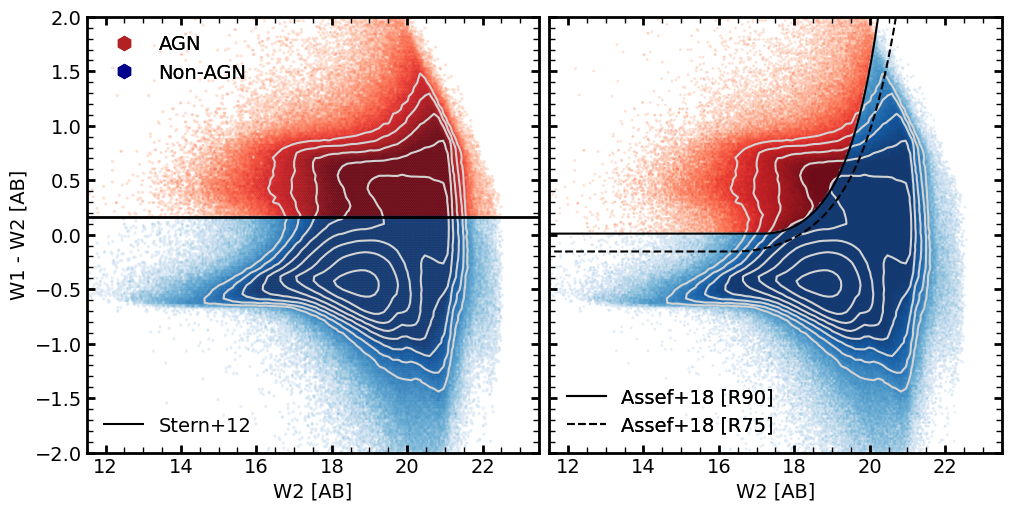

In [7]:
# Stern+12, Assef+18
norm_min, norm_max = 0.3, 300
x_min, x_max, y_min, y_max = 11.5, 23.5, -2.0, 2.0

is_stern12_agn = (agngal['IR_TYPE'] & ir_type.WISE_AGN_S12 == ir_type.WISE_AGN_S12) & has_w1w2
is_stern12_nonagn = (agngal['IR_TYPE'] & ir_type.WISE_SF_S12 == ir_type.WISE_SF_S12) & has_w1w2

is_assef18_agn = (agngal['IR_TYPE'] & ir_type.WISE_AGN_A18 == ir_type.WISE_AGN_A18) & has_w1w2
is_assef18_nonagn = (agngal['IR_TYPE'] & ir_type.WISE_SF_A18 == ir_type.WISE_SF_A18) & has_w1w2

# All Source Contours
source_density, *_ = np.histogram2d(mag_w2[has_w1w2], color_w1w2[has_w1w2], range=[[x_min, x_max], [y_min, y_max]],
                                    bins=100, density=True)
contour_levels = np.power(10, np.arange(-2.3, 1, 0.3))

fig, axes = plt.subplots(ncols=2, sharey=True, figsize=(5 * 2, 5), constrained_layout=True)

# Stern+12 Single-Color Selection
axes[0].hexbin(mag_w2[is_stern12_agn], color_w1w2[is_stern12_agn], mincnt=1, gridsize=300,
               norm=LogNorm(norm_min, norm_max), alpha=0.5, cmap='Reds')
axes[0].hexbin(mag_w2[is_stern12_nonagn], color_w1w2[is_stern12_nonagn], mincnt=1, gridsize=300,
               norm=LogNorm(norm_min, norm_max), alpha=0.5, cmap='Blues')
axes[0].contour(source_density.T, colors='lightgrey', extent=(x_min, x_max, y_min, y_max), levels=contour_levels)

# Stern selection line
axes[0].axhline(y=0.8 + w1w2_ab_vega_offset, color='k', linewidth=2)
stern_12_handle, = axes[0].plot(np.nan, np.nan, color='k', label='Stern+12')

# Assef+18 Reliability Selection
axes[1].hexbin(mag_w2[is_assef18_agn], color_w1w2[is_assef18_agn], mincnt=1, gridsize=300,
               extent=(x_min, x_max, y_min, y_max), norm=LogNorm(norm_min, norm_max), alpha=0.5, cmap='Reds')
axes[1].hexbin(mag_w2[is_assef18_nonagn], color_w1w2[is_assef18_nonagn], mincnt=1, gridsize=300,
               extent=(x_min, x_max, y_min, y_max), norm=LogNorm(norm_min, norm_max), alpha=0.5, cmap='Blues')
axes[1].contour(source_density.T, colors='lightgrey', extent=(x_min, x_max, y_min, y_max), levels=contour_levels)

# Assef selection lines
xx_assef18_r90, yy_assef18_r90 = assef18_line(reliability=90)
xx_assef18_r75, yy_assef18_r75 = assef18_line(reliability=75)
assef18_r90_handle, = axes[1].plot(xx_assef18_r90, yy_assef18_r90, color='k', ls='-', label='Assef+18 [R90]')
assef18_75_handle, = axes[1].plot(xx_assef18_r75, yy_assef18_r75, color='k', ls='--', label='Assef+18 [R75]')

# Legend
agn_handle, = axes[0].plot(np.nan, np.nan, color='firebrick', marker='h', markersize=1, label='AGN', ls='none')
nonagn_handle, = axes[0].plot(np.nan, np.nan, color='darkblue', marker='h', markersize=1, label='Non-AGN', ls='none')
all_sources_handle, = axes[0].plot(np.nan, np.nan, color='lightgrey', label='All sources')

stern_legend = axes[0].legend(handles=[stern_12_handle], markerscale=10, loc='lower left', frameon=False)
axes[0].add_artist(stern_legend)
assef_legend = axes[1].legend(handles=[assef18_r90_handle, assef18_75_handle], loc='lower left', frameon=False)
axes[1].add_artist(assef_legend)
sources_legend = axes[0].legend(handles=[agn_handle, nonagn_handle], markerscale=10, loc='upper left', frameon=False)
axes[0].add_artist(sources_legend)

axes[0].set(xlabel='W2 [AB]', ylabel='W1 - W2 [AB]', xlim=[x_min, x_max], ylim=[y_min, y_max])
axes[1].set(xlabel='W2 [AB]', xlim=[x_min, x_max], ylim=[y_min, y_max])

fig.savefig('/pscratch/sd/b/bfloyd/figures/WISE_color-mag_selections.pdf', bbox_inches='tight')
fig.savefig('/pscratch/sd/b/bfloyd/figures/WISE_color-mag_selections.png', bbox_inches='tight', dpi=300)
plt.show()

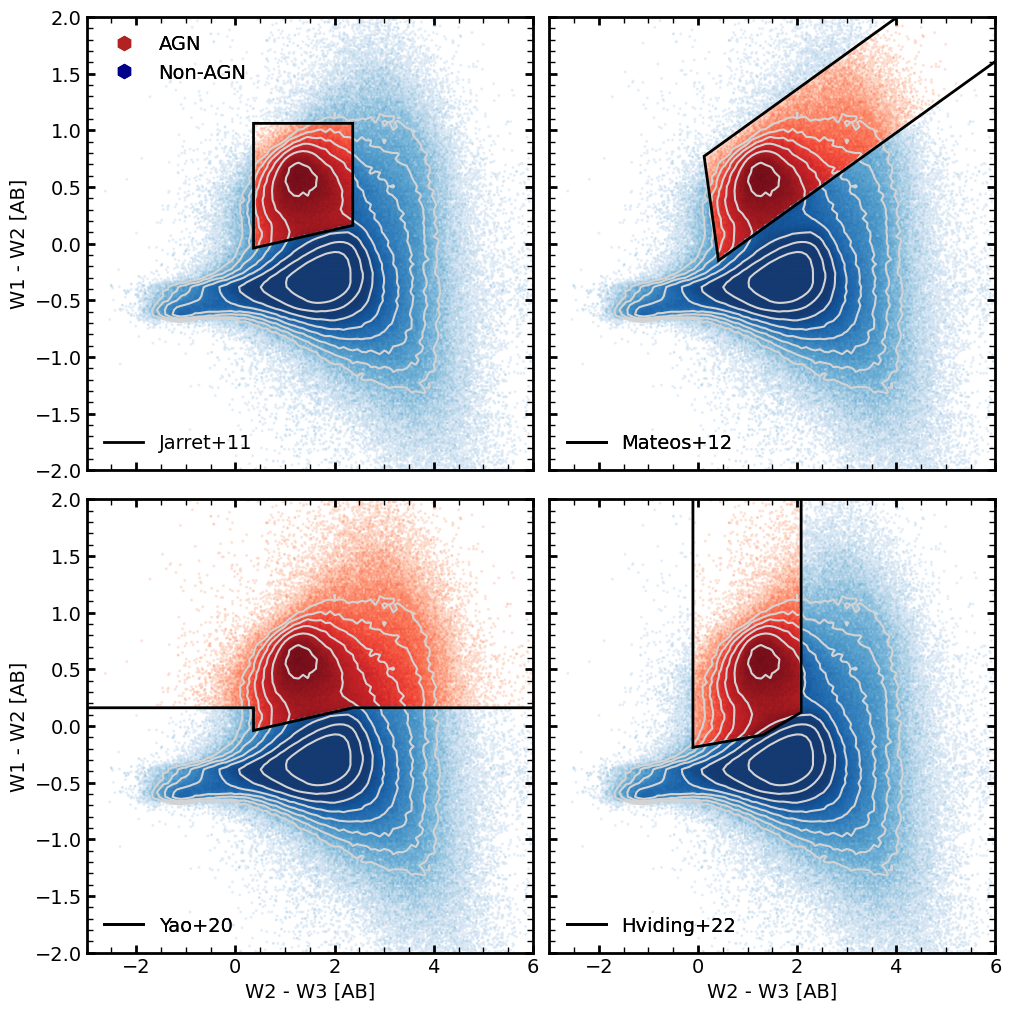

In [8]:
# Jarrett+11, Mateos+12, Yao+20, Hviding+22
norm_min, norm_max = 0.3, 300
x_min, x_max, y_min, y_max = -3.0, 6.0, -2.0, 2.0

is_jarret11_agn = (agngal['IR_TYPE'] & ir_type.WISE_AGN_J11 == ir_type.WISE_AGN_J11) & has_w1w2w3
is_jarret11_nonagn = (agngal['IR_TYPE'] & ir_type.WISE_SF_J11 == ir_type.WISE_SF_J11) & has_w1w2w3

is_mateos12_agn = (agngal['IR_TYPE'] & ir_type.WISE_AGN_M12 == ir_type.WISE_AGN_M12) & has_w1w2w3
is_mateos12_nonagn = (agngal['IR_TYPE'] & ir_type.WISE_SF_M12 == ir_type.WISE_SF_M12) & has_w1w2w3

is_yao20_agn = (agngal['IR_TYPE'] & ir_type.WISE_AGN_Y20 == ir_type.WISE_AGN_Y20) & has_w1w2w3
is_yao20_nonagn = (agngal['IR_TYPE'] & ir_type.WISE_SF_Y20 == ir_type.WISE_SF_Y20) & has_w1w2w3

is_hviding22_agn = (agngal['IR_TYPE'] & ir_type.WISE_AGN_H22 == ir_type.WISE_AGN_H22) & has_w1w2w3
is_hviding22_nonagn = (agngal['IR_TYPE'] & ir_type.WISE_SF_H22 == ir_type.WISE_SF_H22) & has_w1w2w3

# All Source Contours
source_density, *_ = np.histogram2d(color_w2w3[has_w1w2w3], color_w1w2[has_w1w2w3],
                                    range=[[x_min, x_max], [y_min, y_max]], bins=100, density=True)
contour_levels = np.power(10, np.arange(-2.3, 1, 0.3))

fig, axes = plt.subplots(ncols=2, nrows=2, sharey=True, sharex=True, figsize=(5 * 2, 5 * 2), constrained_layout=True)

# Jarret+11 Color-Color Selection
axes[0, 0].hexbin(color_w2w3[is_jarret11_agn], color_w1w2[is_jarret11_agn], mincnt=1, gridsize=300,
                  extent=(x_min, x_max, y_min, y_max), norm=LogNorm(norm_min, norm_max), alpha=0.5, cmap='Reds')
axes[0, 0].hexbin(color_w2w3[is_jarret11_nonagn], color_w1w2[is_jarret11_nonagn], mincnt=1, gridsize=300,
                  extent=(x_min, x_max, y_min, y_max), norm=LogNorm(norm_min, norm_max), alpha=0.5, cmap='Blues')
axes[0, 0].contour(source_density.T, colors='lightgrey', extent=(x_min, x_max, y_min, y_max), levels=contour_levels)

# Jarret+11 Selection Lines
axes[0, 0].add_patch(Polygon(xy=[[2.2 + w2w3_ab_vega_offset, 1.7 + w1w2_ab_vega_offset],
                                 [4.2 + w2w3_ab_vega_offset, 1.7 + w1w2_ab_vega_offset],
                                 [4.2 + w2w3_ab_vega_offset, 0.8 + w1w2_ab_vega_offset],
                                 [2.2 + w2w3_ab_vega_offset, 0.6 + w1w2_ab_vega_offset]],
                             closed=True, ls='-', lw=2, edgecolor='k', facecolor='none', zorder=3))
jarret11_handle, = axes[0, 0].plot(np.nan, np.nan, ls='-', lw=2, color='k', label='Jarret+11')

# Mateos+12 Color-Color Selection
axes[0, 1].hexbin(color_w2w3[is_mateos12_agn], color_w1w2[is_mateos12_agn], mincnt=1, gridsize=300,
                  extent=(x_min, x_max, y_min, y_max), norm=LogNorm(norm_min, norm_max), alpha=0.5, cmap='Reds')
axes[0, 1].hexbin(color_w2w3[is_mateos12_nonagn], color_w1w2[is_mateos12_nonagn], mincnt=1, gridsize=300,
                  extent=(x_min, x_max, y_min, y_max), norm=LogNorm(norm_min, norm_max), alpha=0.5, cmap='Blues')
axes[0, 1].contour(source_density.T, colors='lightgrey', extent=(x_min, x_max, y_min, y_max), levels=contour_levels)

# Mateos+12 Selection Lines
axes[0, 1].add_patch(Polygon(xy=[[10 + w2w3_ab_vega_offset, 3.946 + w1w2_ab_vega_offset],
                                 [1.96 + w2w3_ab_vega_offset, 1.41 + w1w2_ab_vega_offset],
                                 [2.25 + w2w3_ab_vega_offset, 0.49 + w1w2_ab_vega_offset],
                                 [10 + w2w3_ab_vega_offset, 2.928 + w1w2_ab_vega_offset]],
                             closed=False, ls='-', lw=2, edgecolor='k', facecolor='none', zorder=3))
mateos12_handle, = axes[0, 1].plot(np.nan, np.nan, ls='-', lw=2, color='k', label='Mateos+12')

# Yao+20 Color-Color Selection
axes[1, 0].hexbin(color_w2w3[is_yao20_agn], color_w1w2[is_yao20_agn], mincnt=1, gridsize=300,
                  extent=(x_min, x_max, y_min, y_max), norm=LogNorm(norm_min, norm_max), alpha=0.5, cmap='Reds')
axes[1, 0].hexbin(color_w2w3[is_yao20_nonagn], color_w1w2[is_yao20_nonagn], mincnt=1, gridsize=300,
                  extent=(x_min, x_max, y_min, y_max), norm=LogNorm(norm_min, norm_max), alpha=0.5, cmap='Blues')
axes[1, 0].contour(source_density.T, colors='lightgrey', extent=(x_min, x_max, y_min, y_max), levels=contour_levels)

# Yao+20 Selection Lines
axes[1, 0].add_patch(Polygon(xy=[[-10, 0.8 + w1w2_ab_vega_offset],
                                 [2.2 + w2w3_ab_vega_offset, 0.8 + w1w2_ab_vega_offset],
                                 [2.2 + w2w3_ab_vega_offset, 0.6 + w1w2_ab_vega_offset],
                                 [4.2 + w2w3_ab_vega_offset, 0.8 + w1w2_ab_vega_offset],
                                 [10, 0.8 + w1w2_ab_vega_offset]],
                             closed=False, ls='-', lw=2, edgecolor='k', facecolor='none', zorder=3))
yao20_handle, = axes[1, 0].plot(np.nan, np.nan, ls='-', lw=2, color='k', label='Yao+20')

# Hviding+22 Color-Color Selection
axes[1, 1].hexbin(color_w2w3[is_hviding22_agn], color_w1w2[is_hviding22_agn], mincnt=1, gridsize=300,
                  extent=(x_min, x_max, y_min, y_max), norm=LogNorm(norm_min, norm_max), alpha=0.5, cmap='Reds')
axes[1, 1].hexbin(color_w2w3[is_hviding22_nonagn], color_w1w2[is_hviding22_nonagn], mincnt=1, gridsize=300,
                  extent=(x_min, x_max, y_min, y_max), norm=LogNorm(norm_min, norm_max), alpha=0.5, cmap='Blues')
axes[1, 1].contour(source_density.T, colors='lightgrey', extent=(x_min, x_max, y_min, y_max), levels=contour_levels)

# Hviding+22 Selection Lines
axes[1, 1].add_patch(Polygon(xy=[[1.734 + w2w3_ab_vega_offset, 10 + w1w2_ab_vega_offset],
                                 [1.734 + w2w3_ab_vega_offset, 0.45 + w1w2_ab_vega_offset],
                                 [3.15 + w2w3_ab_vega_offset, 0.56 + w1w2_ab_vega_offset],
                                 [3.916 + w2w3_ab_vega_offset, 0.76 + w1w2_ab_vega_offset],
                                 [3.916 + w2w3_ab_vega_offset, 10 + w1w2_ab_vega_offset]],
                             closed=False, ls='-', lw=2, edgecolor='k', facecolor='none', zorder=3))
hviding22_handle, = axes[1, 1].plot(np.nan, np.nan, ls='-', lw=2, color='k', label='Hviding+22')

# Legend
agn_handle, = axes[0, 0].plot(np.nan, np.nan, color='firebrick', marker='h', markersize=1, label='AGN', ls='none')
nonagn_handle, = axes[0, 0].plot(np.nan, np.nan, color='darkblue', marker='h', markersize=1, label='Non-AGN', ls='none')
all_sources_handle, = axes[0, 0].plot(np.nan, np.nan, color='lightgrey', label='All sources')

jarret11_legend = axes[0, 0].legend(handles=[jarret11_handle], loc='lower left', frameon=False)
axes[0, 0].add_artist(jarret11_legend)
mateos12_legend = axes[0, 1].legend(handles=[mateos12_handle], loc='lower left', frameon=False)
axes[0, 1].add_artist(mateos12_legend)
yao20_legend = axes[1, 0].legend(handles=[yao20_handle], loc='lower left', frameon=False)
axes[1, 0].add_artist(yao20_legend)
hviding22_legend = axes[1, 1].legend(handles=[hviding22_handle], loc='lower left', frameon=False)
axes[1, 1].add_artist(hviding22_legend)
sources_legend = axes[0, 0].legend(handles=[agn_handle, nonagn_handle], markerscale=10, loc='upper left', frameon=False)
axes[0, 0].add_artist(sources_legend)

axes[0, 0].set(ylabel='W1 - W2 [AB]', xlim=[x_min, x_max], ylim=[y_min, y_max])
axes[1, 0].set(xlabel='W2 - W3 [AB]', ylabel='W1 - W2 [AB]', xlim=[x_min, x_max], ylim=[y_min, y_max])
axes[1, 1].set(xlabel='W2 - W3 [AB]', xlim=[x_min, x_max], ylim=[y_min, y_max])

fig.savefig('/pscratch/sd/b/bfloyd/figures/WISE_color-color_selections.pdf', bbox_inches='tight')
fig.savefig('/pscratch/sd/b/bfloyd/figures/WISE_color-color_selections.png', bbox_inches='tight', dpi=300)
plt.show()